#Tujuan : Untuk melakukan analisis harga saham PTBA dan membuat prediksi harga dengan menggunakan model prediksi

#Import library

In [1]:
import yfinance as yf

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


#Pengambilan dataset

In [3]:
data = yf.download(tickers= 'PTBA.JK', start= '2015-03-04', end= '2026-03-06')

/tmp/ipykernel_224/2804906418.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers= 'PTBA.JK', start= '2015-03-04', end= '2026-03-06')
[*********************100%***********************]  1 of 1 completed


In [4]:
data

Price,Close,High,Low,Open,Volume
Ticker,PTBA.JK,PTBA.JK,PTBA.JK,PTBA.JK,PTBA.JK
Date,,,,,
2015-03-04,630.359863,646.410693,628.900697,642.033194,8776000
2015-03-05,631.819031,647.869861,625.982365,631.819031,8100000
2015-03-06,637.655701,644.951532,630.359869,631.819035,6959500
2015-03-09,628.900696,634.737361,624.523197,630.359862,6082000
2015-03-10,618.686523,628.900688,615.768191,624.523189,10067500
...,...,...,...,...,...
2026-02-27,2600.000000,2620.000000,2570.000000,2610.000000,9458900
2026-03-02,2750.000000,2750.000000,2610.000000,2620.000000,73917100


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2710 entries, 2015-03-04 to 2026-03-05
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, PTBA.JK)   2710 non-null   float64
 1   (High, PTBA.JK)    2710 non-null   float64
 2   (Low, PTBA.JK)     2710 non-null   float64
 3   (Open, PTBA.JK)    2710 non-null   float64
 4   (Volume, PTBA.JK)  2710 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 127.0 KB


#Pengecekan struktur data

In [6]:
# 1. Ambil level teratas saja dari kolom (Close, High, Low, dst.)
# Ini akan menghilangkan level 'PTBA.JK'
data.columns = data.columns.get_level_values(0)

In [7]:
# 2. Pindahkan 'Date' dari Index menjadi kolom biasa
data = data.reset_index()

In [8]:
# 3. Opsional: Ubah semua nama kolom menjadi huruf kecil (agar sesuai keinginan)
data.columns = [col.lower() for col in data.columns]

In [9]:
# 4. Atur urutan kolom sesuai keinginan
data = data[['date', 'close', 'open', 'high', 'low', 'volume']]

In [10]:
data

,date,close,open,high,low,volume
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500
...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2710 entries, 0 to 2709
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2710 non-null   datetime64[ns]
 1   close   2710 non-null   float64       
 2   open    2710 non-null   float64       
 3   high    2710 non-null   float64       
 4   low     2710 non-null   float64       
 5   volume  2710 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 127.2 KB


<Axes: xlabel='date', ylabel='close'>

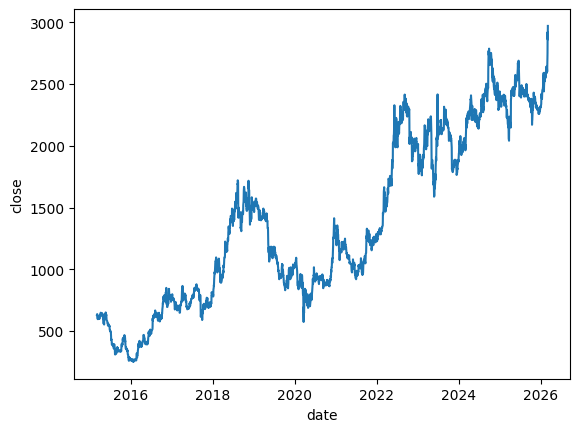

In [12]:
sns.lineplot(data, x = 'date', y = 'close')

In [13]:
#menambahkan data MA20
data['MA20'] = data['close'].rolling(window=20).mean()

In [14]:
data

,date,close,open,high,low,volume,MA20
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN
...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5


In [15]:
#menambahkan data MA50
data['MA50'] = data['close'].rolling(window=50).mean()

In [16]:
data

,date,close,open,high,low,volume,MA20,MA50
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN,NaN
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN,NaN
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN,NaN
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN,NaN
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN,NaN
...,...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0,2456.0
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5,2465.8
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5,2479.0
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5,2491.0


In [17]:
#menambahkan data MA100
data['MA100'] = data['close'].rolling(window=100).mean()

In [18]:
data

,date,close,open,high,low,volume,MA20,MA50,MA100
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN,NaN,NaN
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN,NaN,NaN
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN,NaN,NaN
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN,NaN,NaN
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0,2456.0,2391.1
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5,2465.8,2395.5
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5,2479.0,2401.5
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5,2491.0,2407.0


In [19]:
#menambahkan data MA200
data['MA200'] = data['close'].rolling(window=200).mean()

In [20]:
data

,date,close,open,high,low,volume,MA20,MA50,MA100,MA200
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN,NaN,NaN,NaN
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN,NaN,NaN,NaN
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN,NaN,NaN,NaN
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN,NaN,NaN,NaN
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0,2456.0,2391.1,2422.560693
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5,2465.8,2395.5,2424.154553
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5,2479.0,2401.5,2426.687144
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5,2491.0,2407.0,2428.964100


#Menentukan model

In [21]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

In [22]:
from tensorflow import keras
from tensorflow.keras import layers

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [24]:
import math

In [25]:
#kita hanya akan menggunakan data dari tanggal dan harga close saja
close_price = data['close']

In [26]:
#membuat data training (80%)
#menggunakan values untuk membuang indexnya dan hanya menggunakan angkanya saja sebagai numpy array (angka mentah) agar bisa diolah oleh mesin pencuci data (MinMaxScaler) atau mesin AI (model AI)

values = close_price.values
training_data_len = math.ceil(len(values)*0.8)

In [27]:
scaler = MinMaxScaler (feature_range= (0,1))
scaled_data = scaler.fit_transform(values.reshape(-1,1))
train_data = scaled_data[0: training_data_len, :]

In [28]:
#membuat struktur x-train dan y-train
x_train = []
y_train = []

In [29]:
for i in range (60, len(train_data)) :
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])

In [30]:
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [31]:
#mempersiapkan data test
test_data = scaled_data[training_data_len-60: , :]

In [32]:
x_test = []
y_test = values[training_data_len:]

In [33]:
for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])

In [34]:
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

##Setting LSTM

In [35]:
# 1. Inisialisasi model urutan (Sequential)
model = Sequential()

# 2. Menambahkan lapisan LSTM pertama
# input_shape harus (60, 1) sesuai dengan (time_steps, features) kita tadi
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# 3. Menambahkan lapisan LSTM kedua
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Menambahkan Output Layer (Dense)
model.add(Dense(units=1))

# 5. Mengompilasi model
model.compile(optimizer='adam', loss='mean_squared_error')

print("Arsitektur model berhasil dibuat!")
model.summary()

Arsitektur model berhasil dibuat!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

##Training model LSTM

In [36]:
# Melatih model dengan data training kita
# epochs: berapa kali model melihat seluruh dataset
# batch_size: berapa banyak sampel yang diproses sebelum memperbarui bobot model
model.fit(x_train, y_train, batch_size=20, epochs=2)

Epoch 1/2
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0098
Epoch 2/2
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0019


##Testing model

In [37]:
predictions = model.predict(x_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [38]:
predictions = scaler.inverse_transform(predictions)

In [39]:
rmse = np.sqrt(np.mean(predictions - y_test)**2)

In [40]:
rmse

np.float64(57.94986671363296)

In [41]:
# Rumus MAPE: Rata-rata dari |(Asli - Prediksi) / Asli| * 100
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print(f'MAPE Model: {mape:.2f}%')

MAPE Model: 9.52%


#Visualisasi

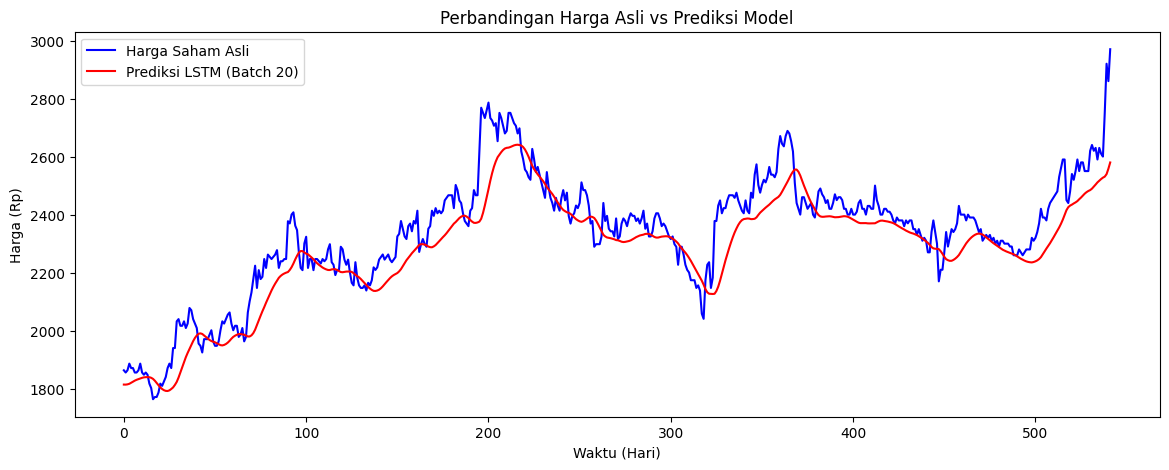

In [42]:
# 1. Menentukan ukuran grafik
plt.figure(figsize=(14,5))

# 2. Membuat plot untuk harga asli (y_test)
plt.plot(y_test, color='blue', label='Harga Saham Asli')

# 3. Membuat plot untuk hasil prediksi
plt.plot(predictions, color='red', label='Prediksi LSTM (Batch 20)')

# 4. Menambahkan judul dan label
plt.title('Perbandingan Harga Asli vs Prediksi Model')
plt.xlabel('Waktu (Hari)')
plt.ylabel('Harga (Rp)')
plt.legend()

# 5. Tampilkan
plt.show()

#Membuat prediksi harga untuk 1 hari kedepan (Besok)

In [43]:
#1. mengambil data 60 hari terakhir (mundur 60 hari dari data yang tersedia)
last_60_days = scaled_data[-60:]

In [44]:
# 2. Reshape menjadi (1, 60, 1)
last_60_days_reshaped = np.reshape(last_60_days, (1, 60, 1))

In [45]:
# 3. Melakukan prediksi
prediction_scaled = model.predict(last_60_days_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [46]:
# 4. Mengembalikan ke harga asli
prediction_price = scaler.inverse_transform(prediction_scaled)

print(f"Prediksi Harga Close untuk besok: Rp{prediction_price[0][0]:.2f}")

Prediksi Harga Close untuk besok: Rp2607.57


In [47]:
# Menghitung MA20 dari data asli
data['MA20'] = data['close'].rolling(window=20).mean()

# Mengambil nilai MA20 terakhir
last_ma20 = data['MA20'].iloc[-1]
current_price = data['close'].iloc[-1]

print(f"Harga Terakhir: Rp{current_price:,.2f}")
print(f"Nilai MA20 saat ini: Rp{last_ma20:,.2f}")
print(f"Prediksi Besok (AI): Rp{prediction_price[0][0]:,.2f}")

Harga Terakhir: Rp2,970.00
Nilai MA20 saat ini: Rp2,647.00
Prediksi Besok (AI): Rp2,607.57


#Membuat Prediksi 7 Hari Kedepan dengan Multi Variate

In [48]:
# 1. Selain harga penutupan (close) kita menggunakan beberapa indikator tambahan yaitu volume, MA20, MA50 dan MA 100 dan indikator MACD
# 2. MA20 dan MA50 untuk melihat trend jangka menengah. Jika MA50 diatas MA 100 (GOLDEN CROSS) kondisi sedang uptrend begitu sebaliknya
# 3. MACD bisa digunakan untuk melihat momentum buy or sell dan juga melihat harga sudah terlalu mahal atau masih cukup murah
# 4. Multi Step Prediction :
#.    Metode Rekursif: Prediksi hari ke-1, lalu gunakan hasil prediksi itu untuk memprediksi hari ke-2, dan seterusnya.
#.    Metode Vector Output: Mengubah lapisan terakhir model agar langsung mengeluarkan 7 angka sekaligus (misal: 7 neuron di lapisan Dense terakhir).

## Menyiapkan data multivariate

In [49]:
data

,date,close,open,high,low,volume,MA20,MA50,MA100,MA200
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN,NaN,NaN,NaN
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN,NaN,NaN,NaN
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN,NaN,NaN,NaN
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN,NaN,NaN,NaN
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0,2456.0,2391.1,2422.560693
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5,2465.8,2395.5,2424.154553
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5,2479.0,2401.5,2426.687144
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5,2491.0,2407.0,2428.964100


In [50]:
# Menghitung MACD sederhana
exp1 = data['close'].ewm(span=12, adjust=False).mean()
exp2 = data['close'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

In [51]:
data

,date,close,open,high,low,volume,MA20,MA50,MA100,MA200,MACD,Signal_Line
0,2015-03-04,630.359863,642.033194,646.410693,628.900697,8776000,NaN,NaN,NaN,NaN,0.000000,0.000000
1,2015-03-05,631.819031,631.819031,647.869861,625.982365,8100000,NaN,NaN,NaN,NaN,0.116401,0.023280
2,2015-03-06,637.655701,631.819035,644.951532,630.359869,6959500,NaN,NaN,NaN,NaN,0.671875,0.152999
3,2015-03-09,628.900696,630.359862,634.737361,624.523197,6082000,NaN,NaN,NaN,NaN,0.401014,0.202602
4,2015-03-10,618.686523,624.523189,628.900688,615.768191,10067500,NaN,NaN,NaN,NaN,-0.630575,0.035967
...,...,...,...,...,...,...,...,...,...,...,...,...
2705,2026-02-27,2600.000000,2610.000000,2620.000000,2570.000000,9458900,2571.0,2456.0,2391.1,2422.560693,42.260302,46.398881
2706,2026-03-02,2750.000000,2620.000000,2750.000000,2610.000000,73917100,2586.5,2465.8,2395.5,2424.154553,51.453440,47.409793
2707,2026-03-03,2920.000000,2840.000000,2940.000000,2810.000000,148905100,2608.5,2479.0,2401.5,2426.687144,71.630931,52.254020
2708,2026-03-04,2860.000000,2930.000000,2970.000000,2790.000000,121906900,2624.5,2491.0,2407.0,2428.964100,81.836874,58.170591


In [52]:
# Menghapus baris yang kosong (NaN) karena perhitungan MA
data.dropna(inplace=True)

## Preprocessing 7 hari kedepan

In [53]:
# menggunakan strategi Vector Output. Artinya, kita mengubah lapisan terakhir model agar langsung mengeluarkan 7 angka sekaligus, bukan hanya 1

###1. Menyiapkan fitur (features)

In [54]:
# Memilih fitur yang akan digunakan
features = ['close', 'MA50', 'MA100', 'MACD', 'Signal_Line']
data_multivariate = data[features].values

In [55]:
# Melakukan Scaling untuk semua kolom
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_multivariate)

In [56]:
# Melakukan Scaling untuk semua kolom
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_multivariate)

###2. Menyiapkan data label untuk 7 hari

In [57]:
# input parameter (X) adalah terdiri dari 5 indikator yaitu close, MA50, MA100, MACD, Signal_Line
# target (Y) adalah harga close 7 hari kedepan

In [58]:
#karena ada 5 fitur maka bentuknya /shape nya adalah (jumlah_sample, 60, 5)

In [59]:
# struktur modelnya akan berubah menjadi :
# input shape menjadi (60, 5)
# output layer : lapisan terakhir (Dense) harus memiliki 7 neuron karena harus mengeluarkan prediksi 7 harga dalam 7 hari berturut-turut sekaligus

In [60]:
model = Sequential()

# Lapisan 1: Input sekarang punya 5 fitur
model.add(LSTM(units=50, return_sequences=True, input_shape=(60, 5)))
model.add(Dropout(0.2))

# Lapisan 2
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Lapisan Output: Mengeluarkan 7 angka untuk 7 hari ke depan
model.add(Dense(units=7))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
# dalam array scaled_data close ada di index ke-0, MA20 index ke-1, MA50 index ke-2, MA100 ke-3, MACD index 4 dan signal_line index 5

X = []
y = []

# Kita loop sampai (panjang data - 7 hari ke depan)
for i in range(60, len(scaled_data) - 7):
    # Mengambil 60 hari ke belakang (semua 5 fitur)
    X.append(scaled_data[i-60:i, 0:5])

    # Mengambil 7 hari ke depan (hanya kolom Close di indeks 0)
    y.append(scaled_data[i:i+7, 0])

# Ubah ke numpy array agar bisa diproses LSTM
X, y = np.array(X), np.array(y)

###3. Melatih model

In [62]:
# Melatih model dengan batch_size=20
history = model.fit(
    X, y,
    batch_size=20,
    epochs=10, # Anda bisa menyesuaikan jumlah epoch
    verbose=1
)

Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0228
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0080
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0061
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.0052
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0043
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0037
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0035
Epoch 8/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0033
Epoch 9/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0029
Epoch 10/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0030


###4. Testing Model

In [63]:
# 1. Ambil 60 hari terakhir (5 fitur)
last_60_days = scaled_data[-60:]
# 2. Reshape ke 3D (1 batch, 60 hari, 5 fitur)
last_60_days_reshaped = np.reshape(last_60_days, (1, 60, 5))

# 3. Prediksi (Outputnya 7 angka dalam skala 0-1)
prediction_scaled = model.predict(last_60_days_reshaped)

# 4. Proses Inverse (Menyiapkan 5 kolom dummy)
dummy_array = np.zeros((7, 5))
dummy_array[:, 0] = prediction_scaled[0] # Masukkan prediksi ke kolom Close
prediction_final = scaler.inverse_transform(dummy_array)[:, 0] # Ambil hasil inverse-nya

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step


In [64]:
for i, harga in enumerate(prediction_final, 1):
    print(f"Hari ke-{i}: Rp {harga:,.2f}")

Hari ke-1: Rp 2,756.11
Hari ke-2: Rp 2,742.16
Hari ke-3: Rp 2,743.50
Hari ke-4: Rp 2,759.06
Hari ke-5: Rp 2,724.61
Hari ke-6: Rp 2,726.90
Hari ke-7: Rp 2,708.45


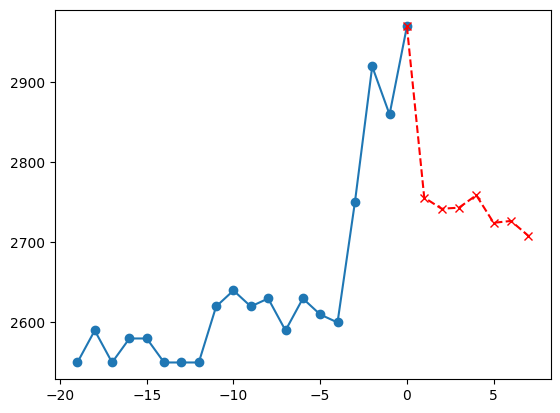

In [65]:
# 1. Menyelaraskan rentang (20 titik)
history_range = range(-19, 1)
predict_range = range(0, 8) # Mulai dari 0 agar menyambung dengan hari ini

# 2. Menambahkan harga hari ini ke awal array prediksi agar garis tersambung
# Kita ambil harga hari ini (titik terakhir dari data asli)
harga_hari_ini = data['close'].values[-1]
# Gabungkan dengan hasil prediksi 7 hari
prediction_plot = np.insert(prediction_final, 0, harga_hari_ini)

# Sekarang kita plot!
plt.plot(history_range, data['close'].values[-20:], label='Harga Historis', marker='o')
plt.plot(predict_range, prediction_plot, label='Prediksi 7 Hari', color='red', linestyle='--', marker='x')

#Backtest

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

Tujuan : untuk mengetahui seberapa jauh error dari prediksi yang telah dibuat

In [67]:
#harga saham PTBA aktual selama 7 hari setelahnya (tgl 6 - 16 maret)
y_true = [2980, 2950, 2950, 2870, 2910, 2910, 2920]

In [68]:
#harga saham PTBA selama 7 hari kedepan sesuai prediksi ML (tgl 6-16 maret)
y_pred = prediction_final

In [74]:
y_pred

array([2756.11347113, 2742.15840137, 2743.49733593, 2759.06009975,
       2724.60717383, 2726.89778936, 2708.44577982])

In [75]:
#Menghitung MAE (Mean Absolute Error) = rata-rata absolut kesalahan antara prediksi dan kenyataan
mae = mean_absolute_error(y_true, y_pred)


In [76]:
#Menghitung RMSE (Root Mean Square Error) = RMSE mirip dengan MAE, tetapi selisihnya dikuadratkan dulu sebelum dirata-rata, baru kemudian diakarkan.
#Kelebihan: Memberikan "hukuman" lebih berat pada kesalahan yang besar. Jika model meleset jauh di satu hari, RMSE akan melonjak tinggi.
#Ini membantu kita melihat apakah model sering membuat kesalahan fatal.
rmse = np.sqrt(mean_squared_error(y_true, y_pred))


In [77]:
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 189.88856411335246
RMSE: 193.06787380638625


In [79]:
df_evaluasi = pd.DataFrame({
    'harga_aktual' : y_true,
    'harga_prediksi' : prediction_final
})

In [80]:
df_evaluasi

,harga_aktual,harga_prediksi
0,2980,2756.113471
1,2950,2742.158401
2,2950,2743.497336
3,2870,2759.060100
4,2910,2724.607174
5,2910,2726.897789
6,2920,2708.445780


In [82]:
df_evaluasi['selisih_harga'] = df_evaluasi['harga_aktual'] - df_evaluasi['harga_prediksi']
df_evaluasi['%_selisih'] = df_evaluasi['selisih_harga']/df_evaluasi['harga_aktual']*100

In [83]:
df_evaluasi

,harga_aktual,harga_prediksi,selisih_harga,%_selisih
0,2980,2756.113471,223.886529,7.512971
1,2950,2742.158401,207.841599,7.045478
2,2950,2743.497336,206.502664,7.000090
3,2870,2759.060100,110.939900,3.865502
4,2910,2724.607174,185.392826,6.370887
5,2910,2726.897789,183.102211,6.292172
6,2920,2708.445780,211.554220,7.245008


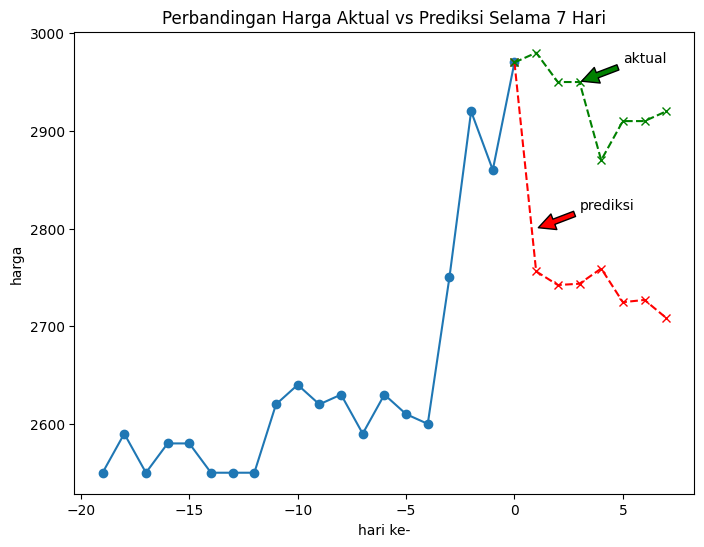

In [104]:
# 1. Menyelaraskan rentang (20 titik)
history_range = range(-19, 1)
predict_range = range(0, 8) # Mulai dari 0 agar menyambung dengan hari ini
true_range =range(0,8)

# 2. Menambahkan harga hari ini ke awal array prediksi agar garis tersambung
# Kita ambil harga hari ini (titik terakhir dari data asli)
harga_hari_ini = data['close'].values[-1]
# Gabungkan dengan hasil prediksi 7 hari
prediction_plot = np.insert(prediction_final, 0, harga_hari_ini)
true_plot = np.insert(y_true,0,harga_hari_ini)

# Sekarang kita plot!
plt.figure(figsize=(8,6))
plt.plot(history_range, data['close'].values[-20:], label='Harga Historis', marker='o')
plt.plot(predict_range, prediction_plot, label='Prediksi 7 Hari', color='red', linestyle='--', marker='x')
plt.plot(true_range,true_plot,label='Aktual 7 Hari', color='green', linestyle='--', marker='x')
plt.xlabel('hari ke-')
plt.ylabel ('harga')
plt.title('Perbandingan Harga Aktual vs Prediksi Selama 7 Hari')
plt.annotate('prediksi', xy=(1,2800), xytext=(3,2820),arrowprops=dict(facecolor='red', shrink = 0.05))
plt.annotate('aktual', xy=(3,2950), xytext=(5,2970),arrowprops=dict(facecolor='green', shrink = 0.05))
plt.show()

#Kesimpulan :

*   Dari data diatas didapat data harga prediksi dibawah harga aktual. Ini bisa menjadi sinyal positif bahwa harga tidak terlalu berambisi sebagai seorang trader, tetapi juga cukup bias karena sinyal juga cukup besar perbedaannya.

*   Perbedaan ini juga dimungkinkan karena ada beberapa faktor yang terjadi saat pengambilan data yaitu faktor geopolitik yang masih belum kondusif dan cenderung meningkat sehingga kondisi pasar sangat volatil. Kemudian tekanan faktor eksternal terhadap IHSG juga mendominasi yaitu dari beberapa lembaga seperti MSCI. Dan juga kondisi ekonomi nasional yang masih belum stabil seperti defisit anggaran yang cenderung meningkat karena faktor eksternal. Dan faktor-faktor eksternal ini tidak tercakup dalam studi prediksi ini.

*   Perlu memasukkan beberapa indikator lain sebagai variabel dalam studi ini seperti volume atau news dll atau adjustment parameter training seperti epoch, panjang data dll

*   Perlu dilakukan evaluasi ulang terhadap model yang dibuat untuk mendapatkan model yang lebih presisi dan melakukan testing ulang dimasa mendatang




